<a href="https://colab.research.google.com/github/shweta1sen/NumPy-Basics/blob/main/Assignment_1_March2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [609]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # scikit-learn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score


In [610]:
# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
#dataset = pd . read_csv ( f {' path }/ Housing . csv ’)
dataset = pd.read_csv(f'{path}/Housing.csv')

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


In [611]:
dataset.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [612]:
dataset.shape

(545, 13)

In [613]:
categorical_columns = dataset.select_dtypes(include=['object']).columns
dataset[categorical_columns]


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [614]:
print('Categorical columns :', len(categorical_columns))

Categorical columns : 7


In [615]:
integer_columns = dataset.select_dtypes(include=['int64']).columns
dataset[integer_columns]

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [616]:
print('Integer Columns : ', len(integer_columns))
#print('Float Columns : ', len(float_columns))
#print('Object Columns : ', len(object_columns))

Integer Columns :  6


In [617]:
categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [618]:
integer_columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [619]:
dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [620]:
dataset.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


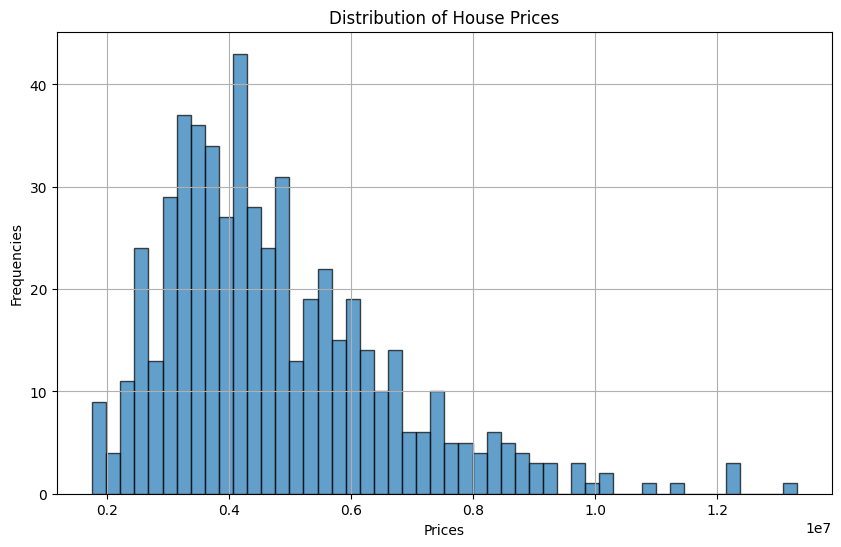

In [621]:
plt.figure(figsize=(10, 6))
plt.hist(dataset['price'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of House Prices')
plt.xlabel('Prices')
plt.ylabel('Frequencies')
plt.grid(True)
plt.show()

In [622]:
#reproducibility
np.random.seed(42)

# **Data Processing for the model**


In [623]:
# target output
y = dataset['price']
X = dataset[['area', 'bedrooms','bathrooms','stories','mainroad','guestroom']]

X.shape, y.shape

((545, 6), (545,))

In [624]:
# splitting the datasaet into training and validation
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2, random_state=42)

In [625]:
X_Train.shape, X_Test.shape

((436, 6), (109, 6))

In [626]:
categorical_columns = X_Train.select_dtypes(include=['object']).columns
print("Categorical columns : ", categorical_columns)

integer_columns = X_Train.select_dtypes(include=['int64']).columns
print("Integer columns : ", integer_columns)



Categorical columns :  Index(['mainroad', 'guestroom'], dtype='object')
Integer columns :  Index(['area', 'bedrooms', 'bathrooms', 'stories'], dtype='object')


In [627]:
#assign these columns to the traning & test dataset
X_Train_Cat = X_Train[categorical_columns]
X_Test_Cat = X_Test[categorical_columns]

X_Train_Int = X_Train[integer_columns]
X_Test_Int = X_Test[integer_columns]


In [628]:
X_Train_Cat.head(20)

,mainroad,guestroom
46,yes,no
93,yes,no
335,yes,no
412,yes,no
471,yes,no
237,yes,no
544,yes,no
470,no,no
511,no,no
361,yes,no


In [629]:
X_Train_Int.head()

,area,bedrooms,bathrooms,stories
46,6000,3,2,4
93,7200,3,2,1
335,3816,2,1,1
412,2610,3,1,2
471,3750,3,1,2


In [630]:
#using one hot encoding to make the category data into the numeric data

encoder = OneHotEncoder(sparse_output=False, drop='first')
X_Train_Cat_Encoded = encoder.fit_transform(X_Train_Cat)
X_Test_Cat_Enoded = encoder.fit_transform(X_Test_Cat)

In [631]:
X_Train_Cat_Encoded[16]

array([0., 0.])

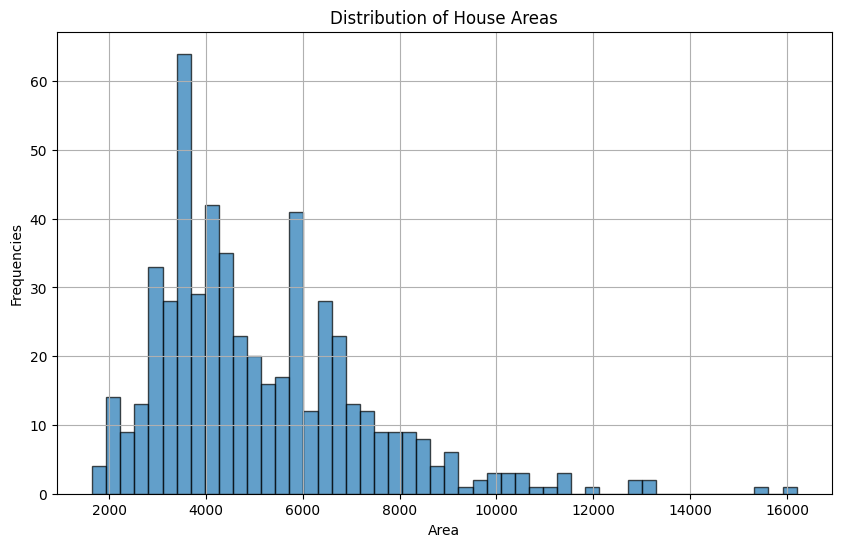

In [632]:
plt.figure(figsize=(10, 6))
plt.hist(dataset['area'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of House Areas')
plt.xlabel('Area')
plt.ylabel('Frequencies')
plt.grid(True)
plt.show()

In [633]:
X_Train_Int['area'].describe()

,area
count,436.000000
mean,5154.144495
std,2204.313664
min,1650.000000
25%,3600.000000
50%,4500.000000
75%,6360.000000
max,16200.000000


In [634]:
#scaling the area to avaoid large computations

standardScale = StandardScaler() # z = (X_val - mean) / std  where mean=0, std=1

X_Train_Int_Scaled = standardScale.fit_transform(X_Train_Int) # computes - Mean, std -> 0,1
X_Test_Int_Scaled = standardScale.fit_transform(X_Test_Int)

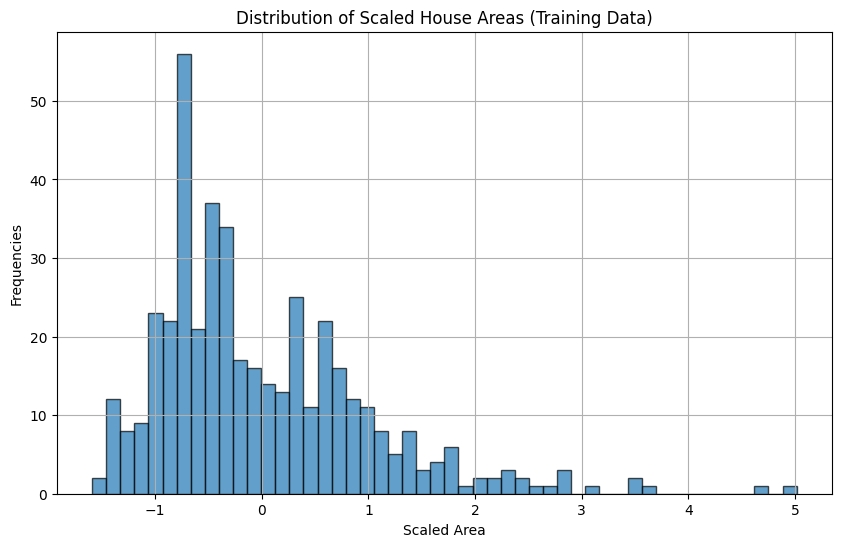

In [635]:
plt.figure(figsize=(10, 6))
plt.hist(X_Train_Int_Scaled[:, 0], bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of Scaled House Areas (Training Data)')
plt.xlabel('Scaled Area')
plt.ylabel('Frequencies')
plt.grid(True)
plt.show()

In [636]:
X_Train_Int['area'].head()

,area
46,6000
93,7200
335,3816
412,2610
471,3750


In [637]:
X_Train_Int_Scaled[:5, 0]

array([ 0.38416819,  0.9291807 , -0.60775457, -1.15549214, -0.63773026])

In [638]:
print('Mean val: ', X_Train_Int_Scaled[:, 0].mean())
print('Std val: ', X_Train_Int_Scaled[:, 0].std())

Mean val:  1.2222638803212733e-16
Std val:  1.0000000000000002


In [639]:
# combined the encoded data and the scaled data into final dataset
X_Train_Final = np.concatenate((X_Train_Cat_Encoded, X_Train_Int_Scaled), axis=1)
X_Test_Final = np.concatenate((X_Test_Cat_Enoded, X_Test_Int_Scaled), axis=1)

X_Train_Final.shape, X_Test_Final.shape

((436, 6), (109, 6))

This completes the data pre-processing. Now comes model development

In [640]:
class LinearRegression:
  def __init__(self, X, y, learningRate, epoch):
    # number of samples
    self.samples = X.size
    self.X = X
    self.y = y
    self.alpha = learningRate
    self.epoch = epoch

    # initiate gradients and weights
    self.bias = 0
    self.wt = np.zeros(X.shape[1])
    self.gradient_b = 0
    self.gradient_w = np.zeros(X.shape[1])
    self.loss_history = []


  # compute mean square error loss function
  def compute_loss(self):
    error = self.y - self.y_hat # dimension N X 1
    loss = 1/(self.samples) * np.dot(error.T, error) # scalar from formula : 1/N sum(y-yhat)^2
    return loss

  # next comes gradients

  def compute_gradient(self):
    self.gradient_b = -(2/self.samples) * np.sum(self.y - self.y_hat)
    self.gradient_w = -(2/self.samples) * np.sum(np.dot(self.X.T, (self.y - self.y_hat) ))


# forward pass > calculate loss > compute gradient > update weights
# run validation loop > decision

  def train(self, show_training_updates = False):  # if the training needs visualisation, make this True
    self.loss_history = []

    for i in range(self.epoch):
      #predict and calculate loss
      self.y_hat = np.dot(self.X, self.wt) + self.bias # y = w.x + b
      loss = self.compute_loss()
      self.loss_history.append(loss)

      #perform optimisation
      self.compute_gradient()

      #update weights
      self.bias = self.bias - (self.alpha * self.gradient_b)
      self.wt = self.wt - (self.alpha * self.gradient_w)
      print(f'Training Loss:: {loss}, Weight: {self.wt}, Bias: {self.bias}, epoch: {i}')


      if show_training_updates:
        plt.figure(figsize=(10, 6), dpi=80)
        plt.title('Training Update Epoch: {}'.format(str(i+1)))
        plt.scatter(self.y, self.y_hat, alpha=0.7)
        plt.plot([self.y.min(), self.y.max()], [self.y_hat.min(), self.y_hat.max()], 'r--', lw=2)
        plt.show()


    return self.bias, self.wt, self.loss_history


  #Predict values for new data
  def predict(self, X):
    return np.dot(X, self.wt) + self.bias


In [641]:
#Training the model

#setting hyper parameters
learningRate = 0.01
epochs = 500

# initiating the model
model = LinearRegression(X_Train_Final, y_Train, learningRate, epochs)

In [642]:
bias, weights, loss_history = model.train(show_training_updates=False)

Training Loss:: 4205798734414.6025, Weight: [28264.22757281 28264.22757281 28264.22757281 28264.22757281
 28264.22757281 28264.22757281], Bias: 15688.424617737004, epoch: 0
Training Loss:: 4102701573265.2676, Weight: [55619.5147733 55619.5147733 55619.5147733 55619.5147733 55619.5147733
 55619.5147733], Bias: 31226.88299697062, epoch: 1
Training Loss:: 4005044625982.8726, Weight: [82093.86671475 82093.86671475 82093.86671475 82093.86671475
 82093.86671475 82093.86671475], Bias: 46619.016011770225, epoch: 2
Training Loss:: 3912503790130.542, Weight: [107714.42903803 107714.42903803 107714.42903803 107714.42903803
 107714.42903803 107714.42903803], Bias: 61868.3556238788, epoch: 3
Training Loss:: 3824774517053.0044, Weight: [132507.51427892 132507.51427892 132507.51427892 132507.51427892
 132507.51427892 132507.51427892], Bias: 76978.32821579624, epoch: 4
Training Loss:: 3741570630716.9717, Weight: [156498.62742653 156498.62742653 156498.62742653 156498.62742653
 156498.62742653 156498.6

In [643]:
weights

array([572149.61774977, 572149.61774977, 572149.61774977, 572149.61774977,
       572149.61774977, 572149.61774977])

In [644]:
bias

np.float64(3274480.0775081003)

In [645]:
title_with_LR = 'Training Loss over Epochs with Learning Rate: ' + str(learningRate)
print(title_with_LR)

Training Loss over Epochs with Learning Rate: 0.01


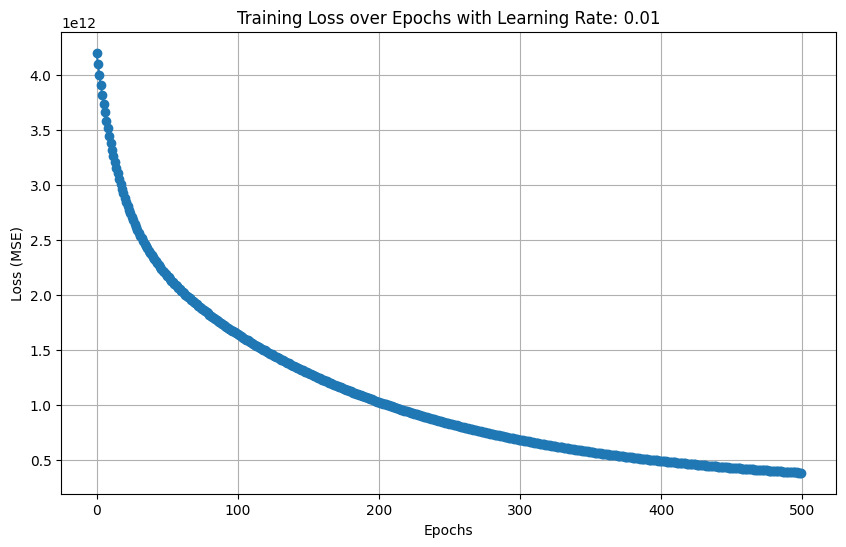

In [646]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history, marker='o', linestyle='-',)
plt.title(title_with_LR)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

In [647]:
# MODEL TESTING NOW
y_Pred = model.predict(X_Test_Final)

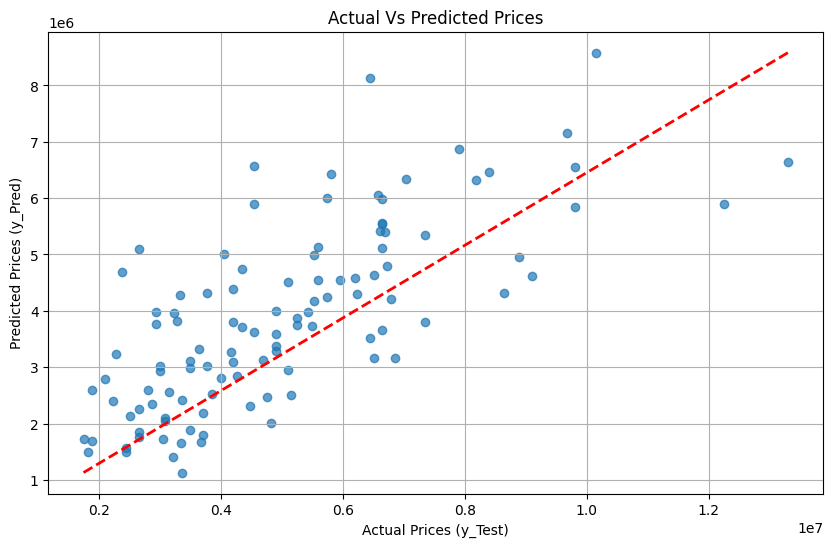

In [648]:
plt.figure(figsize=(10, 6))
plt.scatter(y_Test, y_Pred, alpha=0.7)
plt.plot([y_Test.min(), y_Test.max()], [y_Pred.min(), y_Pred.max()], 'r--', lw=2)
plt.title('Actual Vs Predicted Prices')
plt.xlabel('Actual Prices (y_Test)')
plt.ylabel('Predicted Prices (y_Pred)')
plt.grid(True)
plt.show()

In [649]:
r2 = r2_score(y_Test, y_Pred)
print(f'R2 Score: {r2}')

# R2 Score: -4.337271654878612 with LR = 0.0001 and epoch = 500
# R2 Score: 0.27976470103235296 with LR = 0.01
# R2 Score: 0.49024587566049915 with LR = 0.1

R2 Score: 0.27976470103235296
